---
# TASK 1: DATA COLLECTION and PREPROCESSING

## 1.1 Installing and Importing Dependency

In [1]:
!pip install langchain-community pypdf wordcloud matplotlib nltk scikit-learn adjustText -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [2]:
import re
import os
import time
import nltk
import numpy as np
import pandas as pd
from collections import Counter

import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.tokenize import sent_tokenize
from langchain_community.document_loaders import PyPDFLoader
import string
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words('english'))

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.2 Loading PDFs and Extracting Raw Text from this

In [5]:
PDF_DIR = os.path.expanduser(r"~\Downloads")

pdf_docs_list = [
    "/content/drive/MyDrive/NLU assignment1/doc1.pdf",
    "/content/drive/MyDrive/NLU assignment1/doc2.pdf",
    "/content/drive/MyDrive/NLU assignment1/doc3.pdf",
]

def read_pdf_content(filepath):
    """Extracting all text from a uploaded PDF files using PyPDFLoader"""
    loader = PyPDFLoader(filepath)
    pages = loader.load()
    text = "".join(page.page_content for page in pages)
    return text

raw_texts_dict = {}
for pdf in pdf_docs_list:
    raw_texts_dict[pdf] = read_pdf_content(pdf)
    print(f"Loaded: {pdf}  ({len(raw_texts_dict[pdf]):,} chars)")

print(f"\nTotal no of documents loaded: {len(raw_texts_dict)}")

Loaded: /content/drive/MyDrive/NLU assignment1/doc1.pdf  (121,921 chars)


Loaded: /content/drive/MyDrive/NLU assignment1/doc2.pdf  (40,019 chars)
Loaded: /content/drive/MyDrive/NLU assignment1/doc3.pdf  (246,994 chars)

Total no of documents loaded: 3


## 1.3 Preprocessing phase

1. Removeing boilerplate and formatting artifacts (URLs, emails, page numbers, form feeds)
2. Removeing non-English and non-ASCII text
3. converting in Lowercasing
4. Removeing excessive punctuation and non textual content
5. Tokenizing

In [6]:
def my_tokenize_func(text):
    """Custom tokenizer which splits text on whitespace, then converting tokens to lowercase,
       removes leading or trailing punctuation, filtering out non-alphabetic tokens,
       stopwords, and tokens of length less than or equal to 1."""
    raw_tokens = text.split()
    tokens = []
    for tok in raw_tokens:
        cleaned = tok.strip(string.punctuation).lower()
        if cleaned.isalpha() and len(cleaned) > 1 and cleaned not in STOP_WORDS:
            tokens.append(cleaned)
    return tokens

def clean_and_tokenize(text):
    """Clean raw PDF text then returns cleaned_text and tokens"""

    # Remove boilerplate and formatting artifacts
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'Page\s*\d+', '', text)
    text = re.sub(r'\b\d{1,3}\s*of\s*\d{1,3}\b', '', text)
    text = re.sub(r'\f', '', text)

    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Lowercasing
    text = text.lower()

    # Remove unwanted characters
    text = re.sub(r'[^a-z\s\.]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenization
    tokens = my_tokenize_func(text)

    return text, tokens


clean_docs_map = {}
tok_docs_map = {}

for doc_name, raw_text in raw_texts_dict.items():
    cleaned, tokens = clean_and_tokenize(raw_text)

    clean_docs_map[doc_name] = cleaned
    tok_docs_map[doc_name] = tokens

    print(f"Preprocessed: {doc_name}  →  {len(tokens):,} tokens")

Preprocessed: /content/drive/MyDrive/NLU assignment1/doc1.pdf  →  8,289 tokens
Preprocessed: /content/drive/MyDrive/NLU assignment1/doc2.pdf  →  3,730 tokens
Preprocessed: /content/drive/MyDrive/NLU assignment1/doc3.pdf  →  22,174 tokens


### 1.3.1 Before vs. After Preprocessing phase

In [7]:
doc_one = list(raw_texts_dict.keys())[0]

print()
print("RAW TEXT (first 500 chars):")
print()
print(raw_texts_dict[doc_one][:500])

print()
print("CLEANED TEXT (first 500 chars):")
print()
print(clean_docs_map[doc_one][:500])


RAW TEXT (first 500 chars):

ACADEMIC PROGRAMMES
 
 
 
 
 
Rules & Regulations
 
(
​
For Students enrolled from July 2019 onwards
​
)
 
 
 
 
 
 
 
 
 
 
 
 
 
Indian Institute of Technology Jodhpur
 
 
 
 
 
 
11.
​
 
​
INTRODUCTION
 
Academic
programmes
at
Indian
Institute
of
Technology,
Jodhpur
are
designed
to
develop
the
 
 
 
 
 
 
 
 
 
 
 
 
 
highest
calibre
human
resource
capable
of
understanding
the
new
patterns
of
knowledge
 
 
 
 
 
 
 
 
 
 
 
 
creation
across
disciplines
obliterating
traditional
boundaries
be

CLEANED TEXT (first 500 chars):

academic programmes rules regulations for students enrolled from july onwards indian institute of technology jodhpur . introduction academic programmes at indian institute of technology jodhpur are designed to develop the highest calibre human resource capable of understanding the new patterns of knowledge creation across disciplines obliterating traditional boundaries between science humanities social sciences and engineering. iit

### 1.3.2 Save Cleaned Corpus to Text File

In [8]:
CORPUS_DIR = '/content/drive/MyDrive/NLU assignment1/'

# saveing individual corpora
for idx, (doc_name, cleaned_text) in enumerate(clean_docs_map.items(), start=1):
    individual_path = os.path.join(CORPUS_DIR, f'corpus_{idx}.txt')
    with open(individual_path, 'w', encoding='utf-8') as f:
        f.write(cleaned_text)
    print(f" Saved: {individual_path}  ({os.path.getsize(individual_path):,} bytes)")

# saveing merged corpus
FINAL_CORPUS_PATH = os.path.join(CORPUS_DIR, 'final_corpus.txt')
with open(FINAL_CORPUS_PATH, 'w', encoding='utf-8') as f:
    for doc_name, cleaned_text in clean_docs_map.items():
        f.write(f"{doc_name}\n")
        f.write(cleaned_text)
        f.write("\n\n")

print(f"\n Merged corpus saved to: {FINAL_CORPUS_PATH}")
print(f"  File size: {os.path.getsize(FINAL_CORPUS_PATH):,} bytes")

 Saved: /content/drive/MyDrive/NLU assignment1/corpus_1.txt  (93,460 bytes)
 Saved: /content/drive/MyDrive/NLU assignment1/corpus_2.txt  (36,076 bytes)
 Saved: /content/drive/MyDrive/NLU assignment1/corpus_3.txt  (226,632 bytes)

 Merged corpus saved to: /content/drive/MyDrive/NLU assignment1/final_corpus.txt
  File size: 356,318 bytes


## 1.4 Dataset Statistics

In [9]:
corpus_tokens = []
for tokens in tok_docs_map.values():
    corpus_tokens.extend(tokens)

vocab_set = set(corpus_tokens)

print("Corpus stats:")
print(f"  Docs count: {len(tok_docs_map):,}")
print(f"  Total tokenss: {len(corpus_tokens):,}")
print(f"  Vocab size: {len(vocab_set):,}")
print("")

print("\nPer-Document Breakdown:")
print("")
print(f"{'Document':<45} {'Tokens':>10}")
print("")
for doc_name, tokens in tok_docs_map.items():
    print(f"{doc_name:<45} {len(tokens):>10,}")
print("")

Corpus stats:
  Docs count: 3
  Total tokenss: 34,193
  Vocab size: 6,464


Per-Document Breakdown:

Document                                          Tokens

/content/drive/MyDrive/NLU assignment1/doc1.pdf      8,289
/content/drive/MyDrive/NLU assignment1/doc2.pdf      3,730
/content/drive/MyDrive/NLU assignment1/doc3.pdf     22,174



## 1.5 Word Cloud

In [10]:
valid_tokens = [t for t in corpus_tokens if t not in STOP_WORDS and len(t) > 2]
freq = Counter(valid_tokens)

print("Top 20 frequent words without stop words:")
print("")
for word, count in freq.most_common(20):
    print(f"  {word:<25} {count:>6}")
print("")

Top 20 frequent words without stop words:

  lectures                     772
  course                       438
  learning                     382
  data                         351
  computer                     255
  student                      229
  science                      214
  students                     210
  algorithms                   207
  engineering                  195
  design                       195
  systems                      165
  level                        160
  networks                     154
  introduction                 147
  offered                      145
  type                         142
  applications                 137
  department                   136
  degree                       129



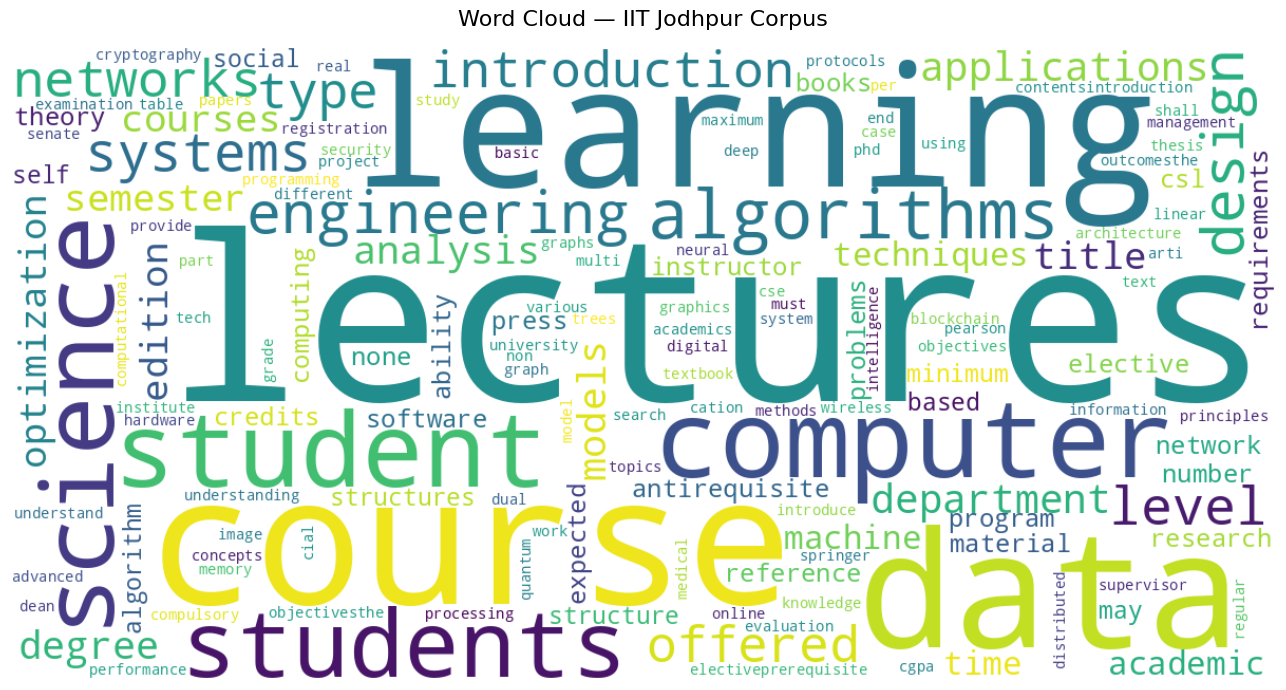

In [11]:
wordcloud = WordCloud(
    width=1200, height=600, max_words=150,
    background_color='white', colormap='viridis', collocations=False,
).generate_from_frequencies(freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — IIT Jodhpur Corpus', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

---
## Prepare Sentences for Word2Vec Training

Convert the tokenised documents into a list of sentences (token lists), removing stopwords and short tokens, ready for the Word2Vec implementation.

In [12]:
# Build 'sentences' list from tok_docs_map
# Each sentence: list of lowercase alpha tokens, stopwords removed, min length 3 tokens

stop_words = STOP_WORDS

# Combine all cleaned text, split into sentences, then tokenize each
raw_text_combined = ' '.join(clean_docs_map.values())
raw_sents = sent_tokenize(raw_text_combined)

sentences = []
for s in raw_sents:
    tokens = my_tokenize_func(s) # Use the my_tokenize_func function
    if len(tokens) >= 3:
        sentences.append(tokens)

print(f'Total no of sentences for Word2Vec: {len(sentences):,}')
print(f'Total tokens:                {sum(len(s) for s in sentences):,}')
print(f'Sample sentence: {sentences[0][:15]}')

Total no of sentences for Word2Vec: 2,421
Total tokens:                33,586
Sample sentence: ['academic', 'programmes', 'rules', 'regulations', 'students', 'enrolled', 'july', 'onwards', 'indian', 'institute', 'technology', 'jodhpur']


---
# TASK-2: MODEL TRAINING

## Word2Vec Implementation Using NumPy

Train two Word2Vec models: **CBOW** and **Skip-gram with Negative Sampling**.

Includes **OOV (Out-of-Vocabulary) handling**: when a query word is not in the vocabulary,
the model automatically finds the closest word using edit distance and uses that instead.

In [13]:
import numpy as np
import time


def _edit_distance(s1, s2):
    """Compute Levenshtein edit distance between two strings."""
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, n + 1):
            temp = dp[j]
            if s1[i-1] == s2[j-1]:
                dp[j] = prev
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j-1])
            prev = temp
    return dp[n]


class Word2VecScrth:
    """Word2Vec CBOW and Skip-gram with Negative Sampling.

    Features:
    - CBOW and Skip-gram architectures
    - Negative sampling with f(w)^0.75 noise distribution
    - OOV handling: finds nearest vocab word by edit distance
    - Vectorized gradient updates + linear LR decay
    """

    NEG_TABLE_SIZE = 100_000_000

    def __init__(self, sentences, vector_size=100, window=5, negative=5,
                 sg=0, min_count=1, epochs=5, lr=0.025, seed=42):
        self.vector_size = vector_size
        self.window = window
        self.negative = negative
        self.sg = sg
        self.epochs = epochs
        self.lr_start = lr
        self.lr = lr
        self.seed = seed
        self.min_count = min_count
        rng = np.random.RandomState(seed)
        self._rng = rng

        # Build vocab_set
        wf = Counter()
        for sent in sentences:
            wf.update(sent)
        self.word2idx, self.idx2word = {}, {}
        freqs = []
        idx = 0
        for word, cnt in wf.items():
            if cnt >= min_count:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                freqs.append(cnt)
                idx += 1
        self.vocab_size = len(self.word2idx)
        self.word_freqs = np.array(freqs, dtype=np.float64)

        # Negative sampling table
        powered = self.word_freqs ** 0.75
        neg_dist = powered / powered.sum()
        ts = min(self.NEG_TABLE_SIZE, max(self.vocab_size * 1000, 1_000_000))
        self.neg_table = np.zeros(ts, dtype=np.int32)
        cum, fi = 0.0, 0
        for wi in range(self.vocab_size):
            cum += neg_dist[wi]
            while fi < ts and (fi / ts) < cum:
                self.neg_table[fi] = wi
                fi += 1
        self.neg_table_size = ts

        # Weights
        sc = 0.5 / self.vector_size
        self.W_in = rng.uniform(-sc, sc, (self.vocab_size, vector_size)).astype(np.float32)
        self.W_out = np.zeros((self.vocab_size, vector_size), dtype=np.float32)

        # Index sentences
        self.indexed_sentences = []
        for sent in sentences:
            ids = [self.word2idx[w] for w in sent if w in self.word2idx]
            if len(ids) >= 2:
                self.indexed_sentences.append(np.array(ids, dtype=np.int32))

        self.training_time = 0.0
        self._train()

    # OOV Handling
    def _resolve_oov(self, word):
        """If word is OOV, find nearest vocab_set word by edit distance."""
        if word in self.word2idx:
            return word
        best_word, best_dist = None, float('inf')
        for vocab_word in self.word2idx:
            d = _edit_distance(word, vocab_word)
            if d < best_dist:
                best_dist = d
                best_word = vocab_word
            if d == 1:
                break  # early stop for 1-edit matches
        print(f'  [OOV] "{word}" not in vocab -> using nearest: "{best_word}" (edit dist={best_dist})')
        return best_word

    # Negative Sampling
    def _get_neg_samples(self, exclude_idx, count):
        negs = self.neg_table[self._rng.randint(0, self.neg_table_size, size=count*2)]
        negs = negs[negs != exclude_idx][:count]
        while len(negs) < count:
            n = self.neg_table[self._rng.randint(0, self.neg_table_size)]
            if n != exclude_idx:
                negs = np.append(negs, n)
        return negs[:count]

    # Training
    def _train(self):
        mode = 'Skip-gram' if self.sg else 'CBOW'
        print(f'Training {mode} | vocab={self.vocab_size:,} | '
              f'dim={self.vector_size} | win={self.window} | '
              f'neg={self.negative} | epochs={self.epochs}')
        t0 = time.time()
        for epoch in range(self.epochs):
            self._rng.shuffle(self.indexed_sentences)
            wc = 0
            for sent in self.indexed_sentences:
                sl = len(sent)
                for pos in range(sl):
                    cid = int(sent[pos])
                    win = self._rng.randint(1, self.window + 1)
                    cs, ce = max(0, pos-win), min(sl, pos+win+1)
                    if self.sg == 0:
                        ctx = [int(sent[j]) for j in range(cs, ce) if j != pos]
                        if not ctx: continue
                        self._cbow(cid, ctx)
                    else:
                        for j in range(cs, ce):
                            if j != pos:
                                self._sgram(cid, int(sent[j]))
                    wc += 1
            prog = (epoch+1) / self.epochs
            self.lr = max(self.lr_start*(1.0-prog), self.lr_start*1e-4)
            print(f'  Epoch {epoch+1}/{self.epochs} | lr={self.lr:.6f} | words={wc:,}')
        self.training_time = time.time() - t0
        print(f'Done in {self.training_time:.1f}s')

    def _cbow(self, cid, ctx):
        lr = self.lr
        h = self.W_in[ctx].mean(axis=0)
        negs = self._get_neg_samples(cid, self.negative)
        tgts = np.empty(1+self.negative, dtype=np.int32); tgts[0]=cid; tgts[1:]=negs
        lbl = np.zeros(1+self.negative, dtype=np.float32); lbl[0]=1.0
        O = self.W_out[tgts]
        sc = 1.0/(1.0+np.exp(-np.clip(O@h,-6,6)))
        g = lr*(lbl-sc)
        gh = g@O
        self.W_out[tgts] += np.outer(g, h)
        gpc = gh/len(ctx)
        for c in ctx: self.W_in[c] += gpc

    def _sgram(self, cid, ctx_id):
        lr = self.lr
        h = self.W_in[cid]
        negs = self._get_neg_samples(ctx_id, self.negative)
        tgts = np.empty(1+self.negative, dtype=np.int32); tgts[0]=ctx_id; tgts[1:]=negs
        lbl = np.zeros(1+self.negative, dtype=np.float32); lbl[0]=1.0
        O = self.W_out[tgts]
        sc = 1.0/(1.0+np.exp(-np.clip(O@h,-6,6)))
        g = lr*(lbl-sc)
        gh = g@O
        self.W_out[tgts] += np.outer(g, h)
        self.W_in[cid] += gh

    # PUBLIC API
    def get_vector(self, word):
        word = self._resolve_oov(word)
        return self.W_in[self.word2idx[word]].astype(np.float64)

    def __contains__(self, word):
        return word in self.word2idx

    def __len__(self):
        return self.vocab_size

    def most_similar(self, word, topn=5):
        word = self._resolve_oov(word)
        vec = self.W_in[self.word2idx[word]].astype(np.float64)
        vec_n = vec / (np.linalg.norm(vec)+1e-10)
        norms = np.linalg.norm(self.W_in, axis=1, keepdims=True).astype(np.float64)+1e-10
        an = self.W_in.astype(np.float64) / norms
        sims = an @ vec_n
        sims[self.word2idx[word]] = -np.inf
        top = np.argsort(sims)[::-1][:topn]
        return [(self.idx2word[int(i)], round(float(sims[i]),4)) for i in top]

    def most_similar_analogy(self, positive, negative, topn=5):
        vec = np.zeros(self.vector_size, dtype=np.float64)
        exclude = set()
        for w in positive:
            w = self._resolve_oov(w)
            vec += self.W_in[self.word2idx[w]].astype(np.float64)
            exclude.add(self.word2idx[w])
        for w in negative:
            w = self._resolve_oov(w)
            vec -= self.W_in[self.word2idx[w]].astype(np.float64)
            exclude.add(self.word2idx[w])
        vec_n = vec / (np.linalg.norm(vec)+1e-10)
        norms = np.linalg.norm(self.W_in, axis=1, keepdims=True).astype(np.float64)+1e-10
        an = self.W_in.astype(np.float64) / norms
        sims = an @ vec_n
        for idx in exclude: sims[idx] = -np.inf
        top = np.argsort(sims)[::-1][:topn]
        return [(self.idx2word[int(i)], round(float(sims[i]),4)) for i in top]

    def save(self, path):
        np.savez(path, W_in=self.W_in, W_out=self.W_out,
                 word2idx=self.word2idx, idx2word=self.idx2word,
                 config=np.array([self.vector_size, self.window,
                                  self.negative, self.sg, self.vocab_size]))
        print(f'Model saved -> {path}')

    @classmethod
    def load(cls, path):
        data = np.load(path, allow_pickle=True)
        obj = object.__new__(cls)
        obj.W_in = data['W_in']; obj.W_out = data['W_out']
        obj.word2idx = data['word2idx'].item()
        obj.idx2word = data['idx2word'].item()
        c = data['config']
        obj.vector_size=int(c[0]); obj.window=int(c[1])
        obj.negative=int(c[2]); obj.sg=int(c[3]); obj.vocab_size=int(c[4])
        return obj


print('Word2Vec class defined which can handle OOV')

Word2Vec class defined which can handle OOV


---
## Hyperparameter Experiments

Varying: **(i) Embedding dimension**, **(ii) Context window**, **(iii) Negative samples**

In [14]:
import pandas as pd

print('EXPERIMENT 1: Varying Embedding Dimension (window=5, neg=5)')
dims = [50, 100, 200]
dim_results = []
for dim in dims:
    for sg in [0, 1]:
        m = Word2VecScrth(sentences=sentences, vector_size=dim, window=5,
            negative=5, sg=sg, min_count=3, epochs=3, lr=0.025, seed=42)
        mode = 'Skip-gram' if sg else 'CBOW'
        nn = m.most_similar('student', topn=3) if 'student' in m else []
        dim_results.append({'Model': mode, 'Dim': dim, 'Win': 5, 'Neg': 5,
            'Vocab': m.vocab_size, 'Time(s)': round(m.training_time, 1),
            'Top-3 NN(student)': ', '.join([w for w,_ in nn]) if nn else 'N/A'})
print('\n'); print(pd.DataFrame(dim_results).to_string(index=False))

EXPERIMENT 1: Varying Embedding Dimension (window=5, neg=5)
Training CBOW | vocab=1,964 | dim=50 | win=5 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 9.9s
Training Skip-gram | vocab=1,964 | dim=50 | win=5 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 29.4s
Training CBOW | vocab=1,964 | dim=100 | win=5 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 11.1s
Training Skip-gram | vocab=1,964 | dim=100 | win=5 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 30.5s
Training CBOW | vocab=1,964 | dim=200 | win=5 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.

In [15]:
print('EXPERIMENT 2: Varying Context Window (dim=100, neg=5)')
windows = [2, 5, 8]
win_results = []
for win in windows:
    for sg in [0, 1]:
        m = Word2VecScrth(sentences=sentences, vector_size=100, window=win,
            negative=5, sg=sg, min_count=3, epochs=3, lr=0.025, seed=42)
        mode = 'Skip-gram' if sg else 'CBOW'
        nn = m.most_similar('student', topn=3) if 'student' in m else []
        win_results.append({'Model': mode, 'Dim': 100, 'Win': win, 'Neg': 5,
            'Time(s)': round(m.training_time, 1),
            'Top-3 NN(student)': ', '.join([w for w,_ in nn]) if nn else 'N/A'})
print('\n'); print(pd.DataFrame(win_results).to_string(index=False))

EXPERIMENT 2: Varying Context Window (dim=100, neg=5)
Training CBOW | vocab=1,964 | dim=100 | win=2 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 10.8s
Training Skip-gram | vocab=1,964 | dim=100 | win=2 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 16.1s
Training CBOW | vocab=1,964 | dim=100 | win=5 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 10.7s
Training Skip-gram | vocab=1,964 | dim=100 | win=5 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 47.9s
Training CBOW | vocab=1,964 | dim=100 | win=8 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008

In [16]:

print('EXPERIMENT 3: Varying Negative Samples (dim=100, window=5)')
negs = [3, 5, 10]
neg_results = []
for neg in negs:
    for sg in [0, 1]:
        m = Word2VecScrth(sentences=sentences, vector_size=100, window=5,
            negative=neg, sg=sg, min_count=3, epochs=3, lr=0.025, seed=42)
        mode = 'Skip-gram' if sg else 'CBOW'
        nn = m.most_similar('student', topn=3) if 'student' in m else []
        neg_results.append({'Model': mode, 'Dim': 100, 'Win': 5, 'Neg': neg,
            'Time(s)': round(m.training_time, 1),
            'Top-3 NN(student)': ', '.join([w for w,_ in nn]) if nn else 'N/A'})
print('\n'); print(pd.DataFrame(neg_results).to_string(index=False))

EXPERIMENT 3: Varying Negative Samples (dim=100, window=5)
Training CBOW | vocab=1,964 | dim=100 | win=5 | neg=3 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 10.8s
Training Skip-gram | vocab=1,964 | dim=100 | win=5 | neg=3 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 29.0s
Training CBOW | vocab=1,964 | dim=100 | win=5 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 10.3s
Training Skip-gram | vocab=1,964 | dim=100 | win=5 | neg=5 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr=0.008333 | words=28,262
  Epoch 3/3 | lr=0.000003 | words=28,262
Done in 28.3s
Training CBOW | vocab=1,964 | dim=100 | win=5 | neg=10 | epochs=3
  Epoch 1/3 | lr=0.016667 | words=28,262
  Epoch 2/3 | lr

---
## Train Final Models

Using **dim=100, window=5, neg=5, epochs=5**

In [17]:
w2v_cbow = Word2VecScrth(sentences=sentences, vector_size=100, window=5,
    negative=5, sg=0, min_count=3, epochs=5, lr=0.025, seed=42)
w2v_cbow.save('word2vec_cbow_final.npz')

Training CBOW | vocab=1,964 | dim=100 | win=5 | neg=5 | epochs=5
  Epoch 1/5 | lr=0.020000 | words=28,262
  Epoch 2/5 | lr=0.015000 | words=28,262
  Epoch 3/5 | lr=0.010000 | words=28,262
  Epoch 4/5 | lr=0.005000 | words=28,262
  Epoch 5/5 | lr=0.000003 | words=28,262
Done in 19.6s
Model saved -> word2vec_cbow_final.npz


In [18]:
sg_model = Word2VecScrth(sentences=sentences, vector_size=100, window=5,
    negative=5, sg=1, min_count=3, epochs=5, lr=0.025, seed=42)
sg_model.save('word2vec_sg_final.npz')

Training Skip-gram | vocab=1,964 | dim=100 | win=5 | neg=5 | epochs=5
  Epoch 1/5 | lr=0.020000 | words=28,262
  Epoch 2/5 | lr=0.015000 | words=28,262
  Epoch 3/5 | lr=0.010000 | words=28,262
  Epoch 4/5 | lr=0.005000 | words=28,262
  Epoch 5/5 | lr=0.000003 | words=28,262
Done in 48.4s
Model saved -> word2vec_sg_final.npz


---
# TASK-3: SEMANTIC ANALYSIS

## Top 5 Nearest Neighbors

Using cosine similarity for: **research, student, phd, exam**

OOV words are automatically resolved to the nearest vocabulary word.

In [19]:
query_words = ['research', 'student', 'phd', 'exam']

print('TOP 5 NEAREST NEIGHBORS (Cosine Similarity)')

print('\n CBOW Model')
for word in query_words:
    neighbors = w2v_cbow.most_similar(word, topn=5)
    print(f'\n  "{word}":')
    for rank, (w, sim) in enumerate(neighbors, 1):
        print(f'    {rank}. {w:<20} (cosine sim = {sim:.4f})')

print('\n Skip-gram Model')
for word in query_words:
    neighbors = sg_model.most_similar(word, topn=5)
    print(f'\n  "{word}":')
    for rank, (w, sim) in enumerate(neighbors, 1):
        print(f'    {rank}. {w:<20} (cosine sim = {sim:.4f})')

TOP 5 NEAREST NEIGHBORS (Cosine Similarity)

 CBOW Model

  "research":
    1. student              (cosine sim = 0.9994)
    2. lectures             (cosine sim = 0.9994)
    3. networks             (cosine sim = 0.9993)
    4. design               (cosine sim = 0.9993)
    5. systems              (cosine sim = 0.9993)

  "student":
    1. systems              (cosine sim = 0.9995)
    2. lectures             (cosine sim = 0.9995)
    3. algorithms           (cosine sim = 0.9995)
    4. networks             (cosine sim = 0.9995)
    5. design               (cosine sim = 0.9995)

  "phd":
    1. software             (cosine sim = 0.9953)
    2. type                 (cosine sim = 0.9952)
    3. introduction         (cosine sim = 0.9950)
    4. systems              (cosine sim = 0.9950)
    5. data                 (cosine sim = 0.9950)
  [OOV] "exam" not in vocab -> using nearest: "team" (edit dist=2)

  "exam":
    1. algorithmic          (cosine sim = 0.9003)
    2. thesis             

## Word Analogy Experiments

**A : B :: C : ?** computed as `vec(B) + vec(C) - vec(A)`

OOV words in analogies are handled automatically.

In [20]:
print('\n')
print('WORD ANALOGY EXPERIMENTS')
print('\n')

analogies = [
    ('ug','btech','pg', 'UG : BTech :: PG : ?'),
    ('bachelor', 'btech', 'master', 'bachelor : btech :: master : ?'),
    ('learning', 'classroom', 'research', 'learning : classroom :: research : ?'),
    ('faculty', 'teaching', 'student', 'faculty : teaching :: student : ?')
]

for mdl, name in [(w2v_cbow,'CBOW'), (sg_model,'Skip-gram')]:
    print(f'\n {name} Model')
    print('-' * 60)
    for A, B, C, label in analogies:
        try:
            result = mdl.most_similar_analogy(positive=[B,C], negative=[A], topn=5)
            top = [f'{w} ({s:.3f})' for w,s in result]
            print(f'  {label}')
            print(f'    => {top}')
        except Exception as e:
            print(f'  {label} => ERROR: {e}')
    print()



WORD ANALOGY EXPERIMENTS



 CBOW Model
------------------------------------------------------------
  [OOV] "btech" not in vocab -> using nearest: "tech" (edit dist=1)
  UG : BTech :: PG : ?
    => ['offered (0.977)', 'electiveprerequisite (0.976)', 'computer (0.975)', 'structure (0.975)', 'type (0.975)']
  [OOV] "btech" not in vocab -> using nearest: "tech" (edit dist=1)
  bachelor : btech :: master : ?
    => ['offered (0.968)', 'science (0.968)', 'csl (0.968)', 'department (0.967)', 'engineering (0.967)']
  learning : classroom :: research : ?
    => ['lynch (-0.269)', 'outcomesat (-0.283)', 'interfacing (-0.318)', 'rogers (-0.346)', 'shirley (-0.363)']
  faculty : teaching :: student : ?
    => ['requirements (0.999)', 'networks (0.999)', 'systems (0.999)', 'algorithms (0.999)', 'semester (0.999)']


 Skip-gram Model
------------------------------------------------------------
  [OOV] "btech" not in vocab -> using nearest: "tech" (edit dist=1)
  UG : BTech :: PG : ?
    => ['mte

---
# TASK-4: VISUALIZATION

## PCA Projection

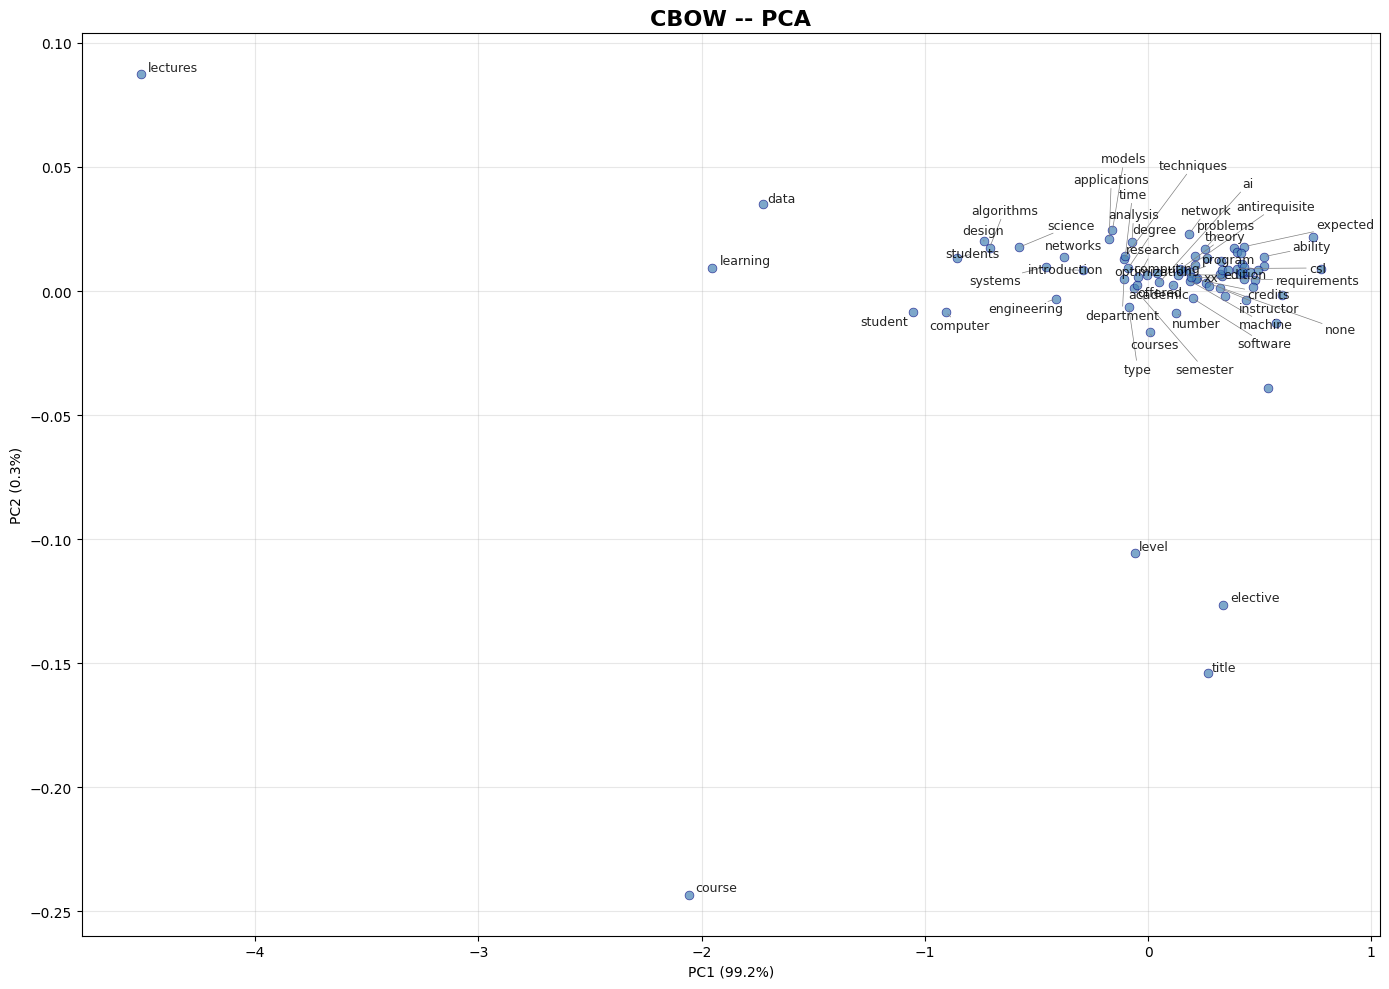

Saved: pca_cbow.png


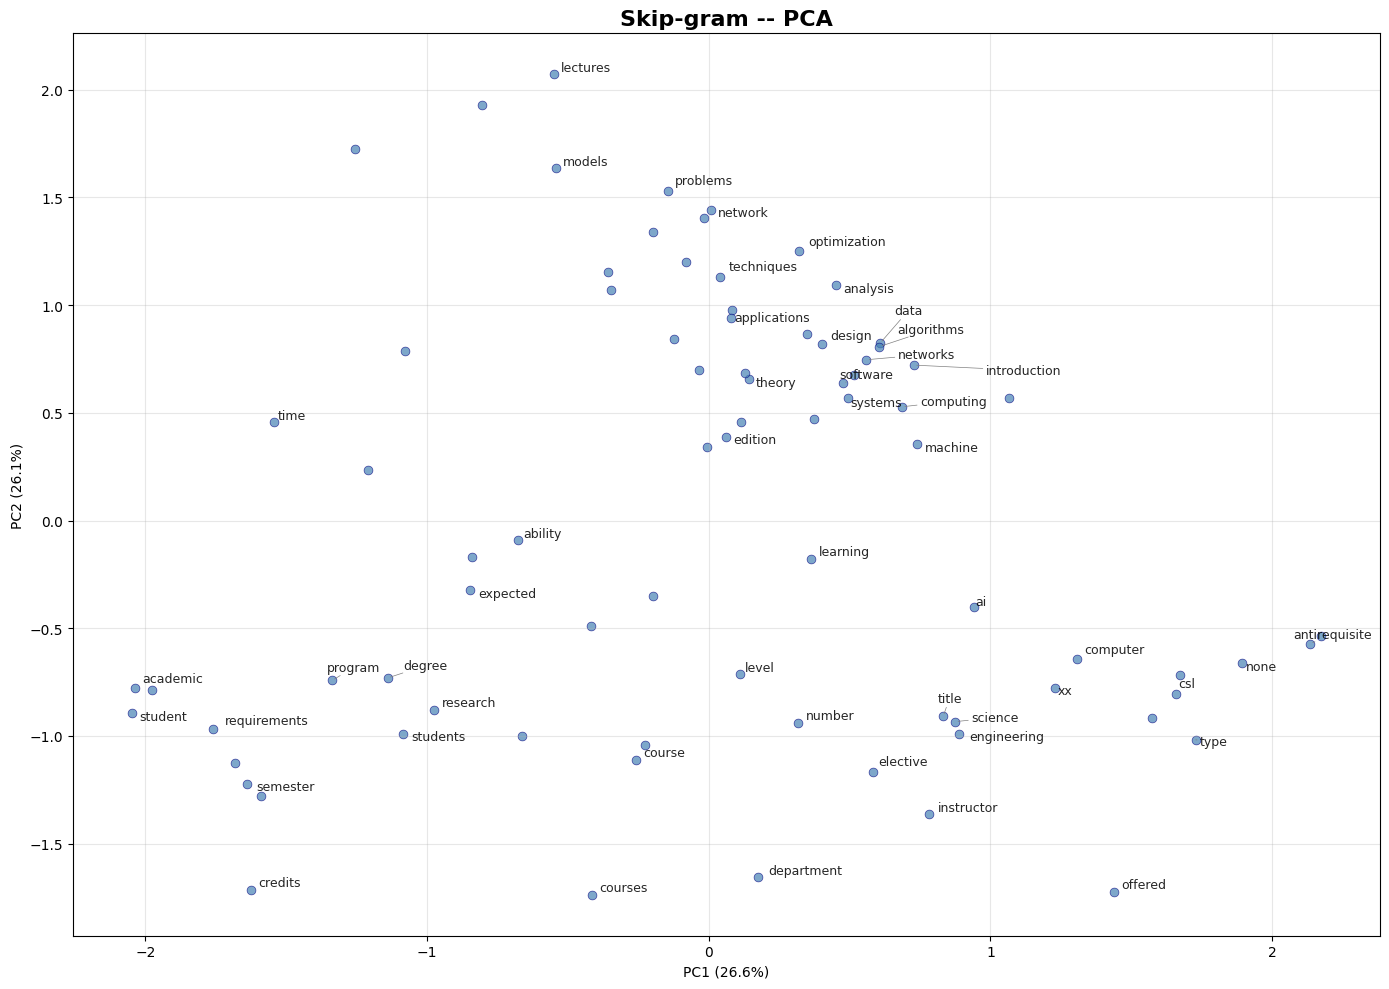

Saved: pca_skip-gram.png


In [21]:
from sklearn.decomposition import PCA
from adjustText import adjust_text

def plot_pca(model, name, top_n=80):
    wf = Counter(); [wf.update(s) for s in sentences]
    words = [w for w,_ in wf.most_common(top_n) if w in model]
    vecs = np.array([model.get_vector(w) for w in words])
    pca = PCA(n_components=2); co = pca.fit_transform(vecs)

    plt.figure(figsize=(14,10))
    plt.scatter(co[:,0], co[:,1], s=40, alpha=0.7, c='steelblue', edgecolors='navy', linewidths=0.5)

    texts = []
    for i,w in enumerate(words[:50]):
        texts.append(plt.text(co[i,0], co[i,1], w, fontsize=9, alpha=0.85))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    plt.title(f'{name} -- PCA', fontsize=16, fontweight='bold')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    fn = f'pca_{name.lower().replace(" ","_")}.png'
    plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); print(f'Saved: {fn}')

plot_pca(w2v_cbow, 'CBOW')
plot_pca(sg_model, 'Skip-gram')

## t-SNE Projection

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


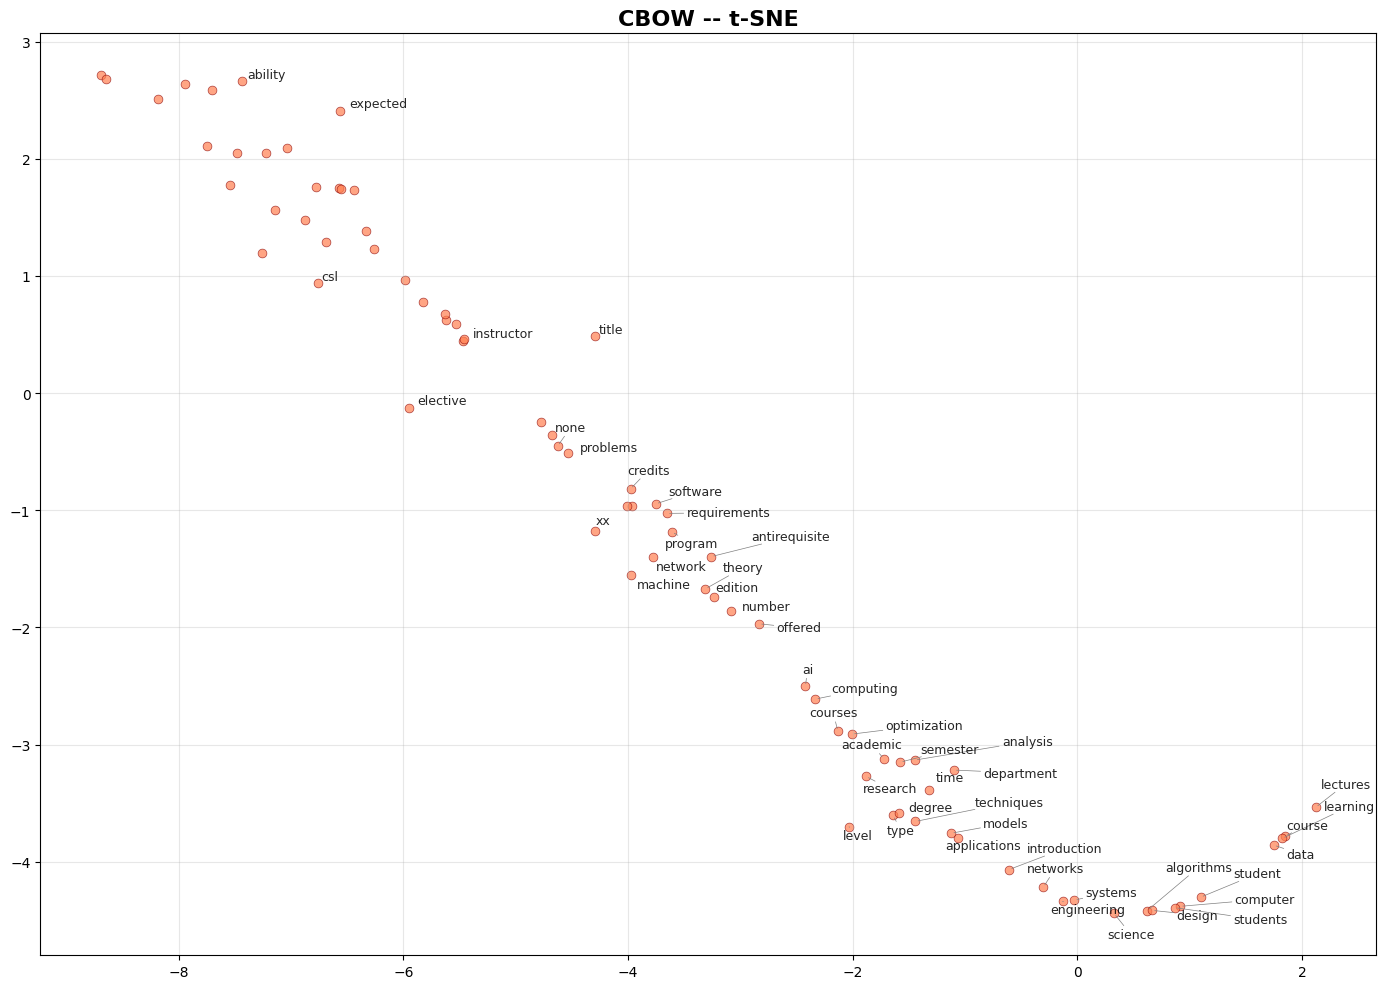

Saved: tsne_cbow.png


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


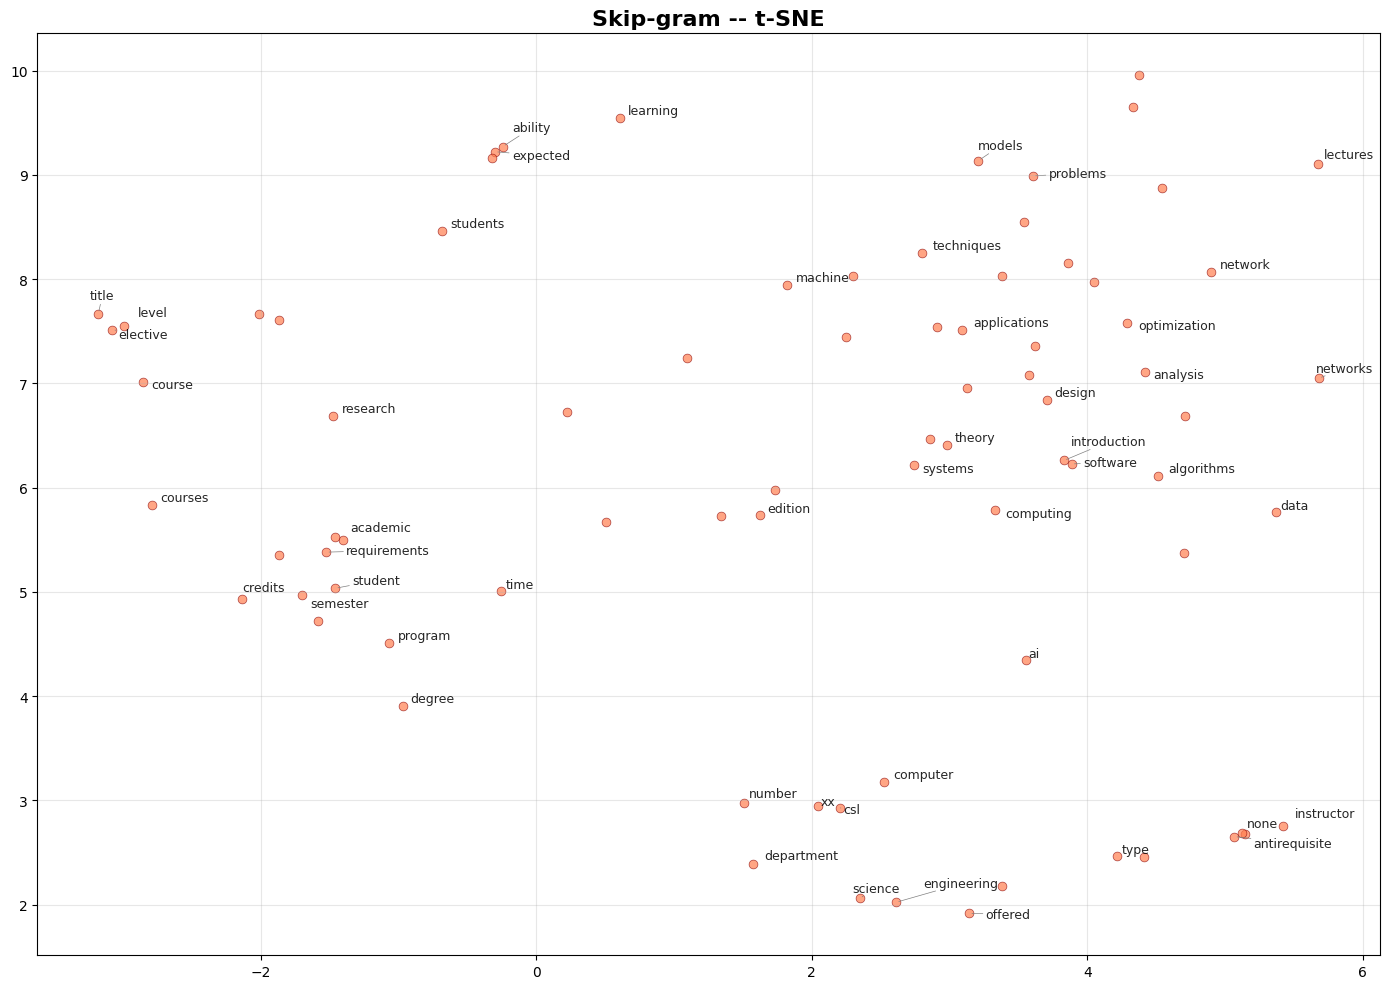

Saved: tsne_skip-gram.png


In [22]:
from sklearn.manifold import TSNE
from adjustText import adjust_text

def plot_tsne(model, name, top_n=80):
    wf = Counter(); [wf.update(s) for s in sentences]
    words = [w for w,_ in wf.most_common(top_n) if w in model]
    vecs = np.array([model.get_vector(w) for w in words])
    co = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000).fit_transform(vecs)

    plt.figure(figsize=(14,10))
    plt.scatter(co[:,0], co[:,1], s=40, alpha=0.7, c='coral', edgecolors='darkred', linewidths=0.5)

    texts = []
    for i,w in enumerate(words[:50]):
        texts.append(plt.text(co[i,0], co[i,1], w, fontsize=9, alpha=0.85))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    plt.title(f'{name} -- t-SNE', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    fn = f'tsne_{name.lower().replace(" ","_")}.png'
    plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); print(f'Saved: {fn}')

plot_tsne(w2v_cbow, 'CBOW')
plot_tsne(sg_model, 'Skip-gram')

## Semantic Category Clustering

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


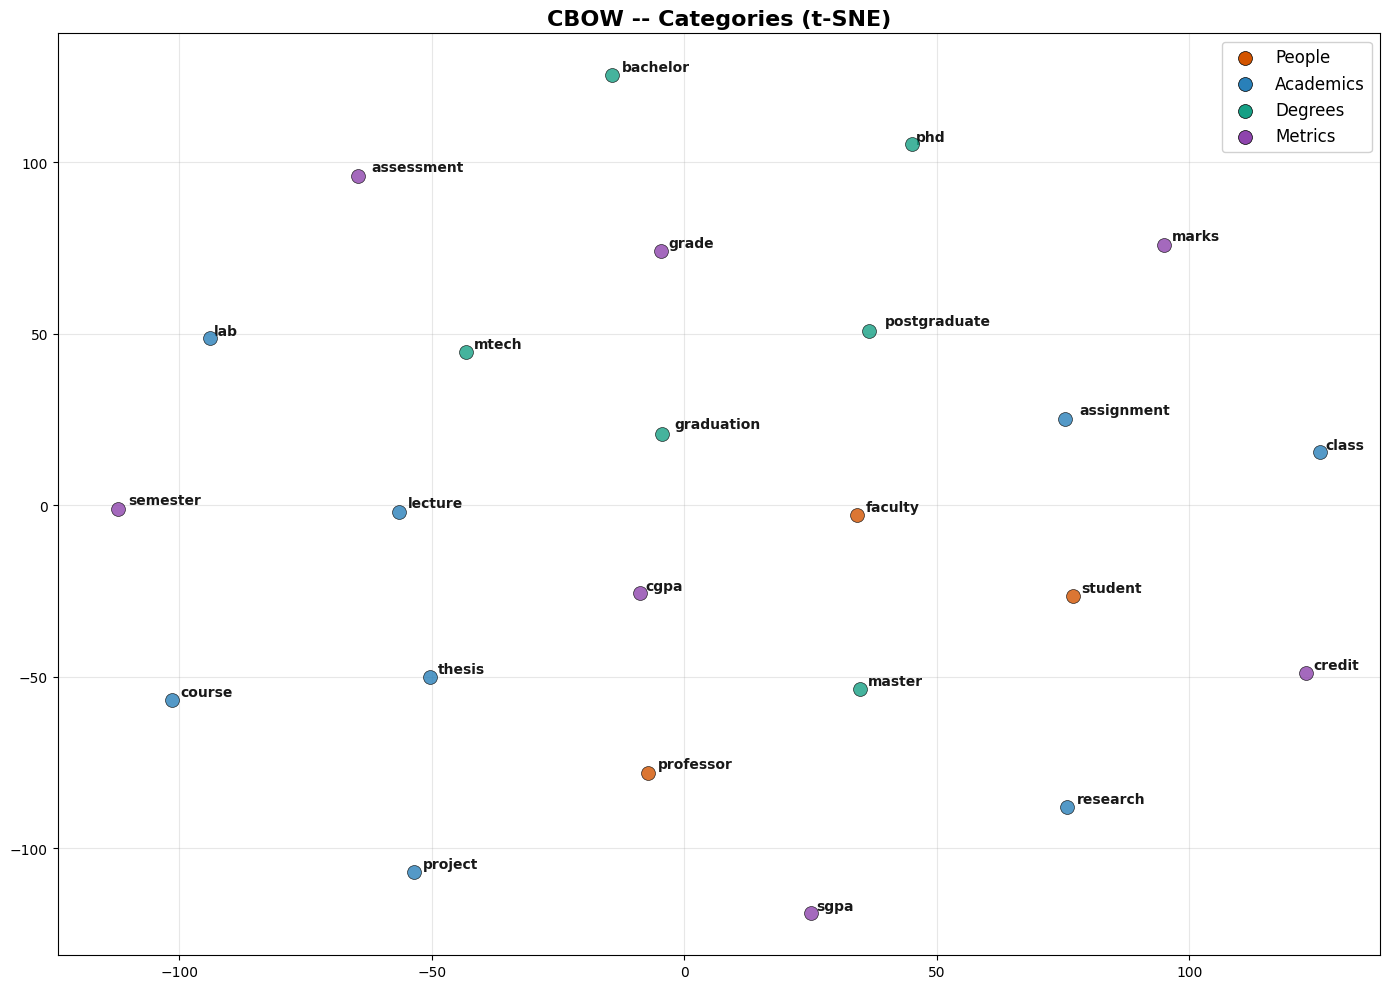

Saved: cat_tsne_cbow.png


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


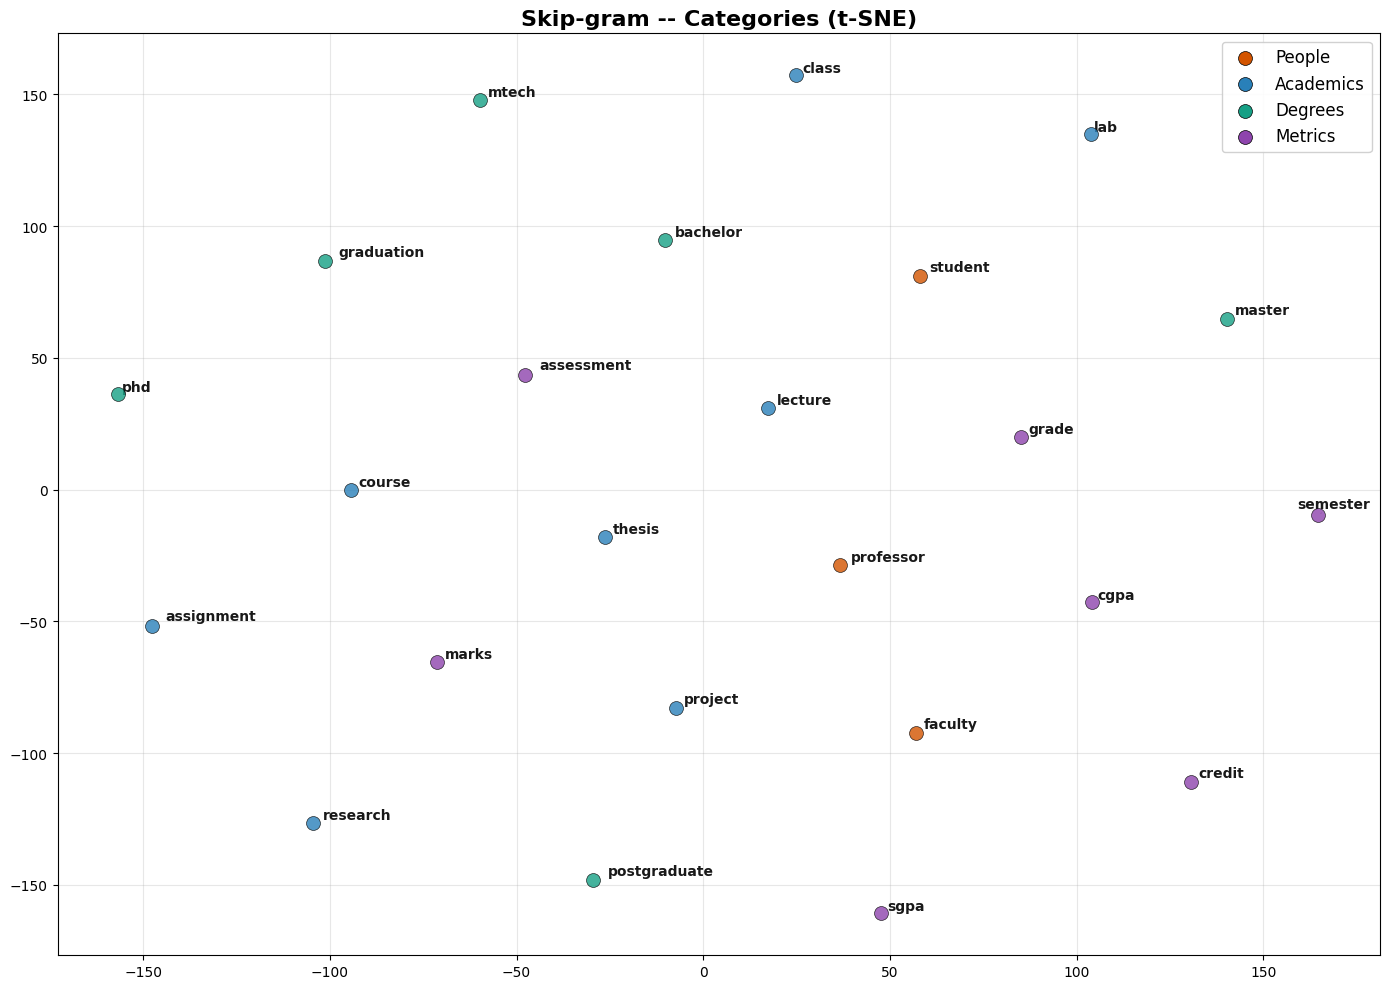

Saved: cat_tsne_skip-gram.png


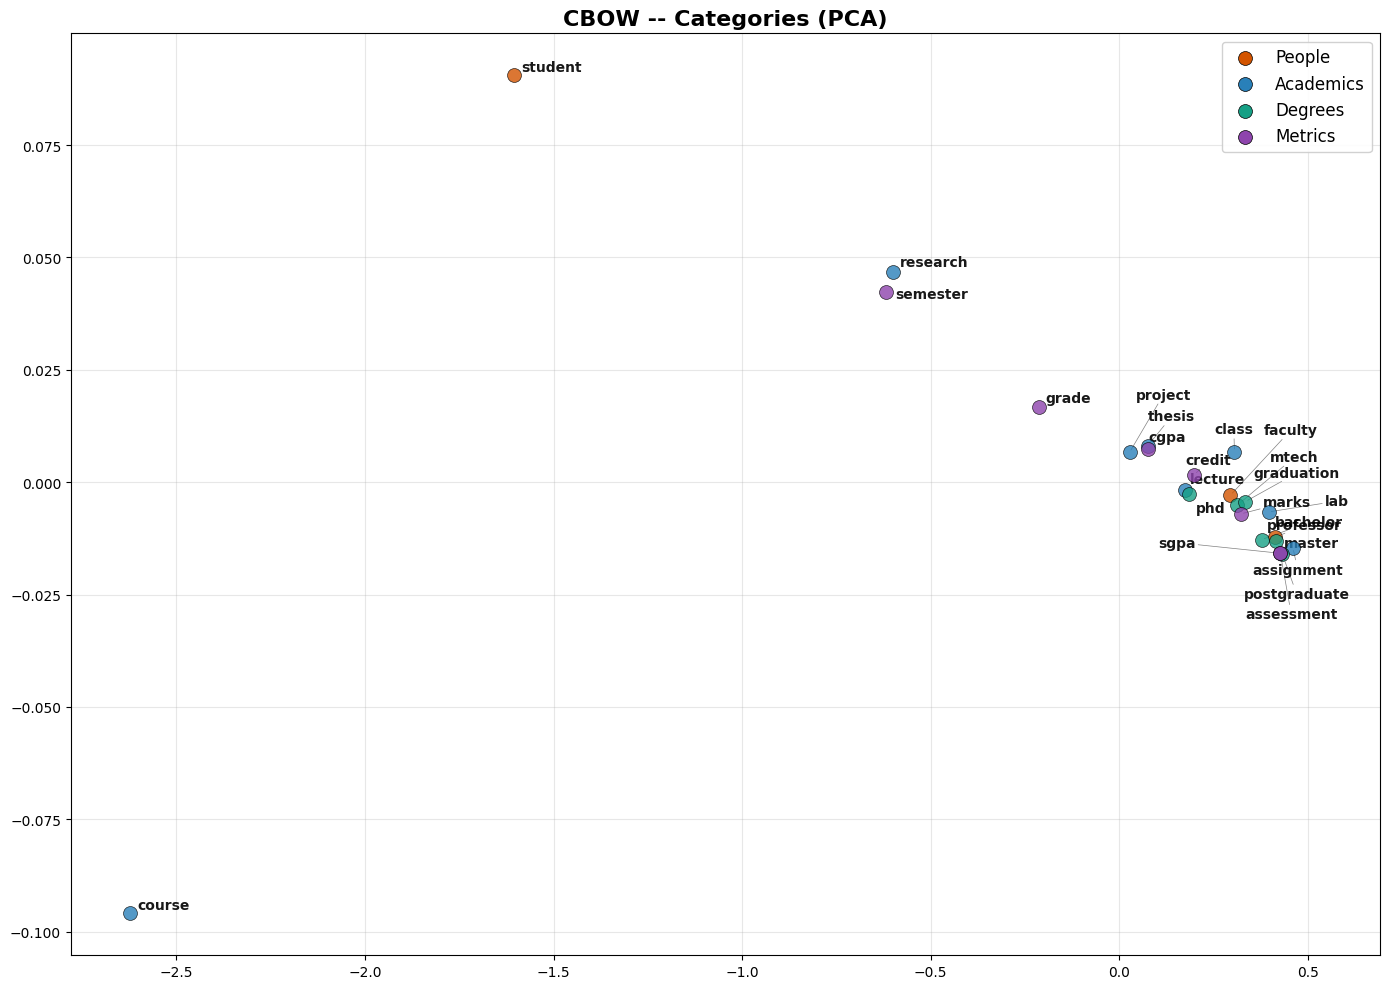

Saved: cat_pca_cbow.png


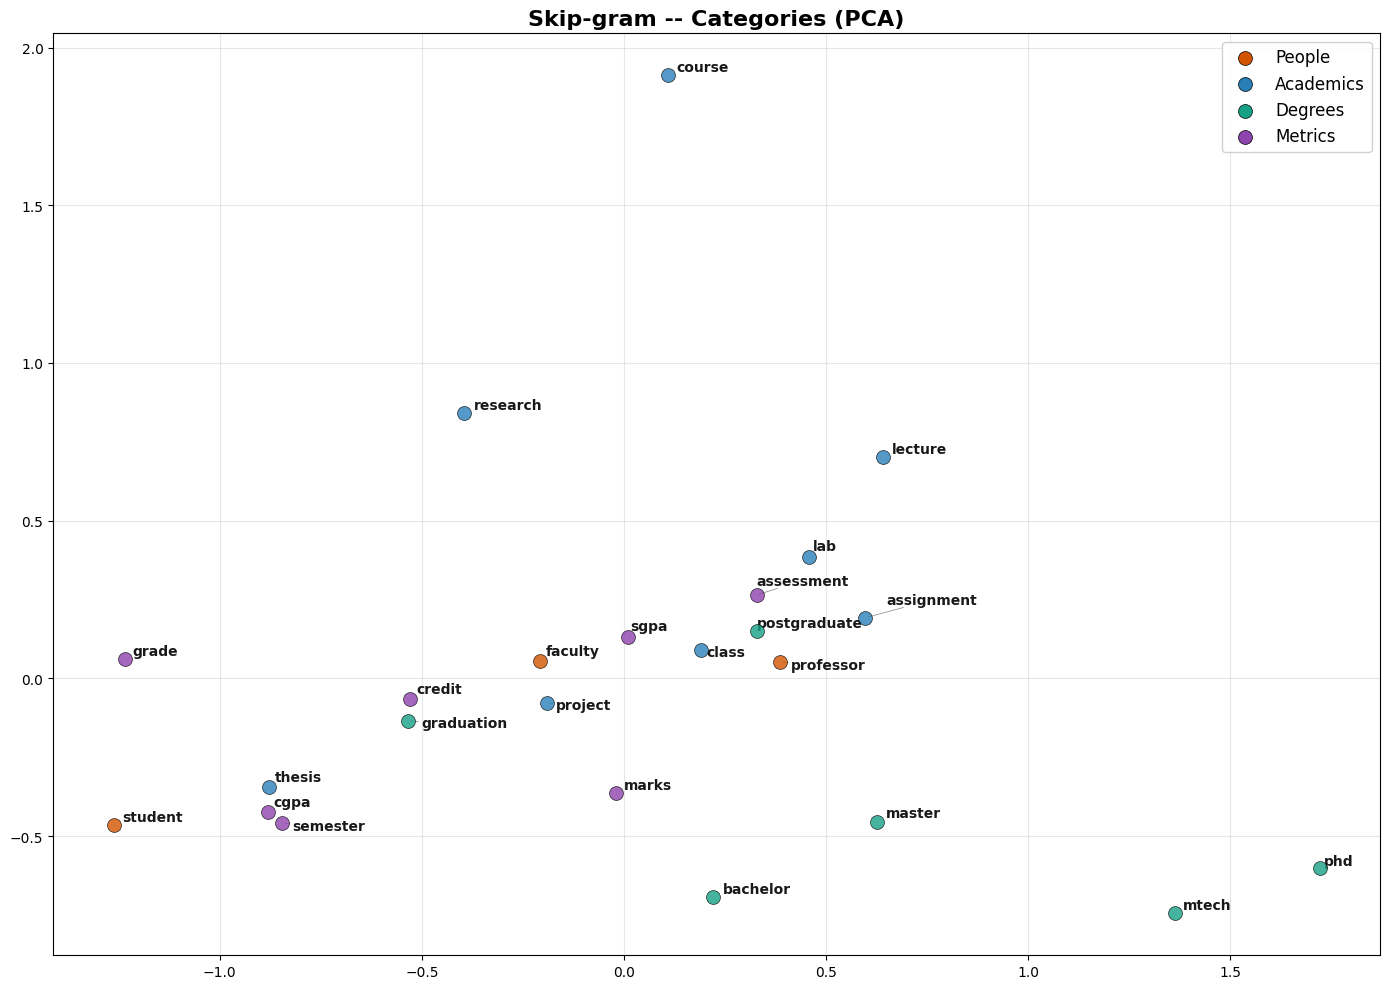

Saved: cat_pca_skip-gram.png


In [23]:
from adjustText import adjust_text

categories = {
    'People':   ['student','faculty','professor','teacher','staff','director','scholars','alumni'],
    'Academics':['course','lecture','class','lab','research','assignment','project','thesis'],
    'Degrees':  ['btech','mtech','phd','msc','bachelor','master','postgraduate','graduation'],
    'Metrics':  ['exam','grade','cgpa','sgpa','marks','assessment','credit','semester'],
}
colors = {'People':'#d35400','Academics':'#2980b9','Degrees':'#16a085','Metrics':'#8e44ad'}

def plot_cat(model, name, method='tsne'):
    ws, ls = [], []
    for cat, wlist in categories.items():
        for w in wlist:
            if w in model: ws.append(w); ls.append(cat)
    if len(ws) < 5: print(f'Not enough words ({len(ws)})'); return
    vecs = np.array([model.get_vector(w) for w in ws])
    if method=='tsne':
        co = TSNE(n_components=2, perplexity=min(30,len(ws)-1), random_state=42, n_iter=1000).fit_transform(vecs)
    else:
        co = PCA(n_components=2).fit_transform(vecs)

    plt.figure(figsize=(14,10))
    texts = []
    for i,(w,l) in enumerate(zip(ws,ls)):
        plt.scatter(co[i,0], co[i,1], c=colors[l], s=100, alpha=0.8, edgecolors='black', linewidths=0.5, zorder=5)
        texts.append(plt.text(co[i,0], co[i,1], w, fontsize=10, fontweight='bold', alpha=0.9))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    for cat,c in colors.items(): plt.scatter([],[],c=c,s=100,label=cat,edgecolors='black',linewidths=0.5)
    plt.legend(fontsize=12, loc='best', framealpha=0.9)
    mt = 't-SNE' if method=='tsne' else 'PCA'
    plt.title(f'{name} -- Categories ({mt})', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    fn = f'cat_{method}_{name.lower().replace(" ","_")}.png'
    plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); print(f'Saved: {fn}')

plot_cat(w2v_cbow, 'CBOW', 'tsne')
plot_cat(sg_model, 'Skip-gram', 'tsne')
plot_cat(w2v_cbow, 'CBOW', 'pca')
plot_cat(sg_model, 'Skip-gram', 'pca')

---
## Final Summary

In [24]:

print('FINAL MODEL COMPARISON')
print(f'{"":<20} {"CBOW":<20} {"Skip-gram":<20}')
print('-' * 60)
print(f'{"Vocab Size":<20} {w2v_cbow.vocab_size:<20,} {sg_model.vocab_size:<20,}')
print(f'{"Embedding Dim":<20} {w2v_cbow.vector_size:<20} {sg_model.vector_size:<20}')
print(f'{"Window Size":<20} {w2v_cbow.window:<20} {sg_model.window:<20}')
print(f'{"Neg Samples":<20} {w2v_cbow.negative:<20} {sg_model.negative:<20}')
print(f'{"Epochs":<20} {w2v_cbow.epochs:<20} {sg_model.epochs:<20}')
print(f'{"Training Time":<20} {w2v_cbow.training_time:<20.1f} {sg_model.training_time:<20.1f}')

for w in ['research','student','phd','exam']:
    cn = [x for x,_ in w2v_cbow.most_similar(w, topn=3)]
    sn = [x for x,_ in sg_model.most_similar(w, topn=3)]
    print(f'\nNearest to "{w}":')
    print(f'  CBOW:      {cn}')
    print(f'  Skip-gram: {sn}')

FINAL MODEL COMPARISON
                     CBOW                 Skip-gram           
------------------------------------------------------------
Vocab Size           1,964                1,964               
Embedding Dim        100                  100                 
Window Size          5                    5                   
Neg Samples          5                    5                   
Epochs               5                    5                   
Training Time        19.6                 48.4                

Nearest to "research":
  CBOW:      ['student', 'lectures', 'networks']
  Skip-gram: ['papers', 'announced', 'materialrelevant']

Nearest to "student":
  CBOW:      ['systems', 'lectures', 'algorithms']
  Skip-gram: ['academics', 'dean', 'thesis']

Nearest to "phd":
  CBOW:      ['software', 'type', 'introduction']
  Skip-gram: ['mtech', 'decided', 'tech']
  [OOV] "exam" not in vocab -> using nearest: "team" (edit dist=2)
  [OOV] "exam" not in vocab -> using nearest: "t

---
## Print Word Embedding Vector

Taking the word 'research' from the vocabulary and printing its embedding vector as a comma-separated list.

In [25]:
word = 'research'
vector = sg_model.get_vector(word)
formatted_vector = ", ".join([f"{val:.4f}" for val in vector])
print(f"{word} - {formatted_vector}")


research - 0.1497, 0.0596, -0.3458, 0.3874, -0.0062, -0.0480, 0.2022, 0.4480, 0.2999, -0.2182, 0.0267, 0.2525, 0.1351, -0.2118, -0.3004, -0.7614, -0.7524, 0.1306, 0.1146, 0.1119, 0.3261, -0.3607, -0.1070, -0.0206, -0.4307, 0.1968, -0.1006, -0.3705, -0.1804, -0.1176, -0.1519, -0.0137, -0.2063, -0.3723, -0.2540, 0.0439, -0.0514, -0.0138, -0.0589, -0.0539, 0.2526, -0.2468, 0.2783, -0.0996, 0.3175, 0.1039, 0.0470, 0.1440, -0.0378, 0.2342, 0.1487, 0.4115, 0.2171, 0.3346, -0.2905, 0.2676, -0.4444, 0.0338, -0.0950, -0.3218, 0.2613, -0.3631, 0.0717, -0.2196, 0.2102, -0.2913, -0.2210, -0.1173, 0.3295, -0.1450, -0.2064, -0.3066, -0.0403, 0.2050, 0.0871, 0.1782, -0.2904, -0.1446, 0.0890, 0.0749, 0.0254, -0.1270, -0.1877, 0.3760, -0.0303, 0.0154, -0.0934, 0.2111, 0.4975, -0.0727, 0.1552, 0.1047, -0.0158, 0.1018, -0.1300, 0.1784, 0.0054, 0.1807, -0.0725, 0.0961
